In [32]:
import os
import pandas as pd
input_utterances = [
    "50", "51", "500", "501", "1000", "1001", "5000", "5001", "10000", "10001" 
]

In [33]:
# read human data for experiment 1
human_data_kettle, human_data_watch, human_data_laptop = {}, {}, {}
exp1_file = os.path.join("human_data", "experiment1-normalized.csv")
with open(exp1_file, 'r') as f:
    lines = f.readlines()
    for line in lines[1:]:
        data = line.strip().split(',')
        if "watch" in data[1]:
            if (data[2], data[6]) in human_data_watch:
                human_data_watch[(data[2], data[6])].append(data[9])
            else:
                human_data_watch[(data[2], data[6])] = [data[9]]    
        elif "kettle" in data[1]:
            if (data[2], data[6]) in human_data_kettle:
                human_data_kettle[(data[2], data[6])].append(data[9])
            else:
                human_data_kettle[(data[2], data[6])] = [data[9]]
        elif "laptop" in data[1]:
            if (data[2], data[6]) in human_data_laptop:
                human_data_laptop[(data[2], data[6])].append(data[9])
            else:
                human_data_laptop[(data[2], data[6])] = [data[9]]
for key in human_data_watch:
    human_data_watch[key] = pd.Series(human_data_watch[key]).astype(float).mean()
for key in human_data_kettle:
    human_data_kettle[key] = pd.Series(human_data_kettle[key]).astype(float).mean()
for key in human_data_laptop:
    human_data_laptop[key] = pd.Series(human_data_laptop[key]).astype(float).mean()


In [34]:
# read model preds
# model_predictions_original = {}
# exp1_file = os.path.join("human_data", "model-predictions.csv")
# with open(exp1_file, 'r') as f:
#     lines = f.readlines()
#     for line in lines[1:]:
#         data = line.strip().split(',')
#         if obj in data[1]:
#             model_predictions_original[(data[2], data[3])] = data[5]
# print(model_predictions_original)

In [35]:


def get_model_predictions(cost):
    model_predictions = {}
    for i, obj in enumerate(["kettle", "watch", "laptop"]):
        model_predictions[obj] = {}
        for utterance in input_utterances:
            args = f"webppl rsa.wppl -- --object {obj} --num {utterance} --cost {cost}"
            output = os.popen(args).read()
            # parse output
            output = output.split("\n")
            for line in output:
                line = line.strip()
                line = line.split(":")
                if len(line) == 2 and "Marginal" not in line[0]:
                    model_predictions[obj][(utterance,str(int(line[0])))] = float(line[1])
                else:
                    continue
    return model_predictions

def normalize_model_predictions(model_predictions, lamb):
    normed_model_predictions = {}
    for obj in model_predictions:
        normed_model_predictions[obj] = {}
        for key in model_predictions[obj]:
            powered = model_predictions[obj][key]**lamb
            utterance = key[0]
            preds_obj_utter = [model_predictions[obj][key]**lamb for key in model_predictions[obj] if key[0] == utterance]
            normed_model_predictions[obj][key] = powered/sum(preds_obj_utter)
    return normed_model_predictions




In [36]:
# run webppl code for all utterances
# us os to run webppl code
cost = [1.0 + x/10 for x in range(0, 30)]
lambda_ = [0.0 + x/100 for x in range(0, 100)]
mses = {}
for c in cost:
    model_predictions = get_model_predictions(c)
    for l in lambda_:
        normed_model_predictions = normalize_model_predictions(model_predictions, l)
        # compare model predictions with human data
        # sum over mse for all objects
        mse = 0
        for obj in ["kettle", "watch", "laptop"]:
            if obj == "watch":
                for key in human_data_watch:
                    mse += (human_data_watch[key] - normed_model_predictions[obj][key])**2
            elif obj == "kettle":
                for key in human_data_kettle:
                    mse += (human_data_kettle[key] - normed_model_predictions[obj][key])**2
            elif obj == "laptop":
                for key in human_data_laptop:
                    mse += (human_data_laptop[key] - normed_model_predictions[obj][key])**2
        mses[(c, l)] = mse

(node:9918) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9919) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9920) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9924) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9925) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9926) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9927) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9931) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9932) [DEP0079] DeprecationWarning: Custom inspection function on Objects via .inspect() is deprecated
(node:9933) [DEP007

In [40]:
back_mses = mses
print(back_mses)

{(1.0, 0.0): 2.6735580307498448, (1.0, 0.01): 2.5811208671906347, (1.0, 0.02): 2.4891186806957566, (1.0, 0.03): 2.397634224356684, (1.0, 0.04): 2.3067556303644388, (1.0, 0.05): 2.2165761826382693, (1.0, 0.06): 2.127194007544381, (1.0, 0.07): 2.0387116812031807, (1.0, 0.08): 1.951235753637399, (1.0, 0.09): 1.864876191949097, (1.0, 0.1): 1.7797457467785944, (1.0, 0.11): 1.695959248426338, (1.0, 0.12): 1.6136328411324286, (1.0, 0.13): 1.5328831660229758, (1.0, 0.14): 1.4538265050581107, (1.0, 0.15): 1.3765778998657172, (1.0, 0.16): 1.301250260536167, (1.0, 0.17): 1.2279534802166936, (1.0, 0.18): 1.1567935716275701, (1.0, 0.19): 1.087871841394442, (1.0, 0.2): 1.021284117345676, (1.0, 0.21): 0.9571200426795926, (1.0, 0.22): 0.8954624492087345, (1.0, 0.23): 0.8363868198050648, (1.0, 0.24): 0.7799608477890102, (1.0, 0.25): 0.7262440984280207, (1.0, 0.26): 0.6752877750469221, (1.0, 0.27): 0.6271345896132303, (1.0, 0.28): 0.581818735151276, (1.0, 0.29): 0.5393659550531347, (1.0, 0.3): 0.4997937

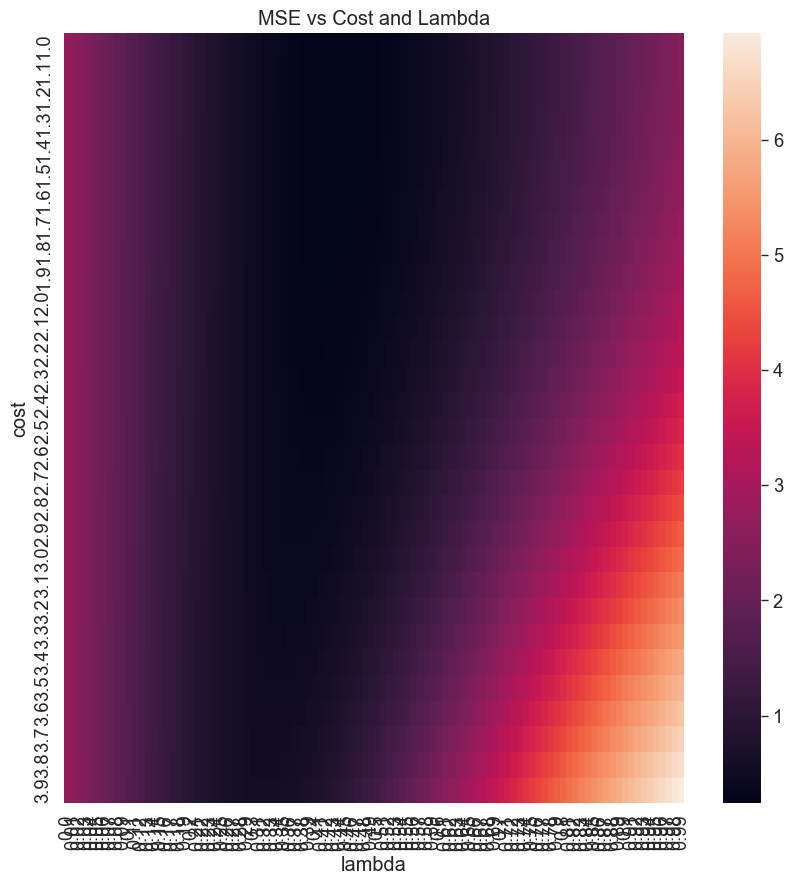

In [41]:
# plot mse vs cost and lambda as a grid
# mse is represented by color
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# convert mses to a matrix
mses_matrix = np.zeros((len(cost), len(lambda_)))
for key in mses.keys():
    mses_matrix[cost.index(key[0]), lambda_.index(key[1])] = mses[key]

# plot
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(mses_matrix, ax=ax, xticklabels=lambda_, yticklabels=cost)
ax.set_xlabel("lambda")
ax.set_ylabel("cost")
ax.set_title("MSE vs Cost and Lambda")
plt.show()

In [45]:
# get all best costs and lambdas
min_mse = min(mses.values())
best_costs = []
best_lambdas = []
for key in mses.keys():
    if mses[key] == min_mse:
        best_costs.append(key[0])
        best_lambdas.append(key[1])

print(best_costs, best_lambdas)
# model_predictions = get_model_predictions(best_cost)
# normed_model_predictions = normalize_model_predictions(model_predictions, best_lambda)
# model_predictions = normed_model_predictions

[1.2] [0.44]


In [43]:
# plot human data and model predictions and show correlation
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
%matplotlib inline

# plot human data and model predictions
# make a list of human data and model predictions
plot_data_kettle = []
plot_data_watch = []
plot_data_laptop = []
for obj in ["kettle", "watch", "laptop"]:
    for key in model_predictions[obj].keys():
        if obj == "kettle":
            plot_data_kettle.append([human_data_kettle[key], model_predictions[obj][key]])
        elif obj == "watch":
            plot_data_watch.append([human_data_watch[key], model_predictions[obj][key]])
        elif obj == "laptop":
            plot_data_laptop.append([human_data_laptop[key], model_predictions[obj][key]])

# plot data
plot_data_kettle = np.array(plot_data_kettle)
plot_data_watch = np.array(plot_data_watch)
plot_data_laptop = np.array(plot_data_laptop)

Correlation for kettle:  0.9375039516448972
Correlation for watch:  0.9803077899583355
Correlation for laptop:  0.9557264826306558


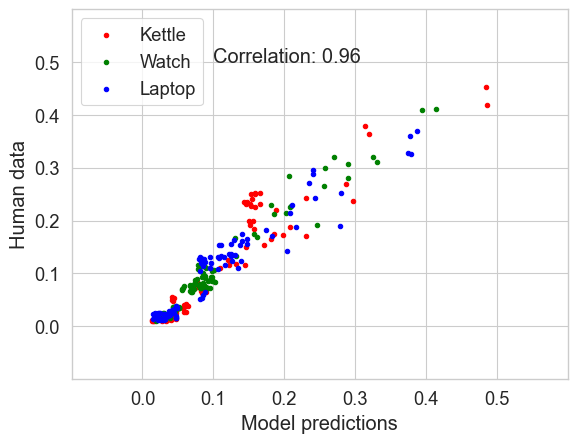

In [44]:
# calculate correlation for each object
corr_kettle, _ = stats.pearsonr(plot_data_kettle[:,0], plot_data_kettle[:,1])
corr_watch, _ = stats.pearsonr(plot_data_watch[:,0], plot_data_watch[:,1])
corr_laptop, _ = stats.pearsonr(plot_data_laptop[:,0], plot_data_laptop[:,1])
print("Correlation for kettle: ", corr_kettle)
print("Correlation for watch: ", corr_watch)
print("Correlation for laptop: ", corr_laptop)

# calculate correlation for all objects
plot_data = np.concatenate((plot_data_kettle, plot_data_watch, plot_data_laptop), axis=0)
corr, _ = stats.pearsonr(plot_data[:,0], plot_data[:,1])

# print correlation
# plot data
# xlim is 0 - 0.5
plt.xlim(-0.1,0.6)
# ylim is 0 - 0.5
plt.ylim(-0.1,0.6)
# ticks are 0, 0.1, 0.2, 0.3, 0.4, 0.5 on both axes
plt.xticks(np.arange(0, 0.6, 0.1))
plt.yticks(np.arange(0, 0.6, 0.1))
# add labels
plt.xlabel("Model predictions")
plt.ylabel("Human data")
# title
# plt.title("RSA for " + obj)
# add legend

# plot data with small shapes, use different colors for objects
plt.scatter(plot_data_kettle[:,1], plot_data_kettle[:,0], s=10, c='r', marker='o', label='Kettle')
plt.scatter(plot_data_watch[:,1], plot_data_watch[:,0], s=10, c='g', marker='o', label='Watch')
plt.scatter(plot_data_laptop[:,1], plot_data_laptop[:,0], s=10, c='b', marker='o', label='Laptop')

# plt.scatter(plot_data[:,1], plot_data[:,0], s=10, c='b', marker='o', label='Model predictions')

plt.legend(loc='upper left')
# plot correlation
plt.text(0.1, 0.5, "Correlation: " + str(round(corr, 2)))

# show plot
plt.show()